# Transformer with PyTorch

In this workshop, we will try to use transformer model to do the sentiment analysis. Below content are adapt from "The Annotated Transformer"(https://nlp.seas.harvard.edu/annotated-transformer/#model-architecture)

Check if GPU has been enabled:

In [ ]:
# imports are always needed
import torch

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()


#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


Using device: cuda

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


/tmp/ipykernel_2115/2550926069.py:15: FutureWarning: `torch.cuda.memory_cached` has been renamed to `torch.cuda.memory_reserved`
  print('Cached:   ', round(torch.cuda.memory_cached(0)/1024**3,1), 'GB')


## Loading dataset

First let's prepare the data. We are using 1000 yelp reviews from last week, which are annotated with either positive or negative sentiments. The dataset preparation process is the same as before.

In [ ]:
import pandas as pd

# same 07-yelp-dataset.txt file from last week.
corpus = "07-yelp-dataset.txt"
df = pd.read_csv(corpus, names=['sentence', 'label'], sep='\t')
print("Number of sentences =", len(df))
print("\nData:")
print(df.iloc[:3])

Number of sentences = 1000

Data:
                                    sentence  label
0                   Wow... Loved this place.      1
1                         Crust is not good.      0
2  Not tasty and the texture was just nasty.      0


In [ ]:
df

,sentence,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


Next, let's create the train/dev/test partitions

In [ ]:
import random
import altair as alt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
#import seaborn
import seaborn as sns

sentences = df['sentence'].values
labels = df['label'].values

#partition data into 80/10/10 for train/dev/test
sentences_train, y_train = sentences[:800], labels[:800]
sentences_dev, y_dev = sentences[800:900], labels[800:900]
sentences_test, y_test = sentences[900:1000], labels[900:1000]

#convert label list into arrays
y_train = np.array(y_train)
y_dev = np.array(y_dev)
y_test = np.array(y_test)

print(y_train[0], sentences_train[0])
print(y_dev[0], sentences_dev[0])
print(y_test[0], sentences_test[0])

1 Wow... Loved this place.
0 I'm super pissd.
0 Spend your money elsewhere.


## Building vocabulary set

Next, we will create tokenise the data and create the vocabulary. Again, we use the same code from last week's workshop.

In [ ]:
import torch
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from nltk.tokenize import word_tokenize
import nltk
import matplotlib.pyplot as plt
import seaborn
from torch.utils.data import DataLoader

import math
import copy

# Download NLTK tokenizer data (run once if not already downloaded)
nltk.download('punkt_tab')

# Assuming sentences_train is your training data (list of strings)
train_iter = sentences_train

# Define a simple tokenizer using NLTK (or you can use another library like spacy)
def tokenizer(text):
    return word_tokenize(text.lower())  # Tokenize and convert to lowercase

# Function to yield tokens from the data
def yield_tokens(data_iter):
    for text in data_iter:
        yield tokenizer(text)

# Build vocabulary manually using Counter
# We add a 'cls' special token here
def build_vocab_from_iterator(token_iterator, specials=('<cls>', '<unk>', '<pad>')):
    counter = Counter()
    for tokens in token_iterator:
        counter.update(tokens)

    # Create vocab dictionary with special tokens
    vocab = {token: idx + len(specials) for idx, (token, _) in enumerate(counter.items())}
    for idx, special in enumerate(specials):
        vocab[special] = idx

    # Reverse mapping (stoi: string to index)
    stoi = vocab
    # Index to string mapping
    itos = {idx: token for token, idx in stoi.items()}

    return stoi, itos, stoi['<unk>']

# Build the vocabulary
vocab, index_to_vocab, default_index = build_vocab_from_iterator(yield_tokens(train_iter), specials=('<cls>', '<unk>', '<pad>'))
padding_index = vocab['<pad>']

# Use CountVectorizer with the custom tokenizer and vocabulary
vectorizer = CountVectorizer(
    tokenizer=tokenizer,
    vocabulary=vocab,  # Pass the string-to-index mapping
    lowercase=True
)

# Example usage (assuming sentences_train is a list of strings)
# vectorized_data = vectorizer.fit_transform(sentences_train)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
vectorized_data = vectorizer.fit_transform(sentences_train)
vocab_size = vectorized_data.shape[1]
print("Vocab size =", vocab_size)

Vocab size = 1813


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


# **Transformer Model Architecture**

Please compare the fuctions with the orginal Transformer achitecure from the paper "[Attention is all you need](https://arxiv.org/pdf/1706.03762)".

<img src="https://www.researchgate.net/publication/372074536/figure/fig3/AS:11431281172072236@1688440508020/Schematic-of-the-Transformer-architecture-2-19.png" alt="Transformer" width="600"/>

We'll now build a transformer model for sentiment analysis. Unlike RNNs, which process sequences from left to right, transformers use self-attention. This mechanism allows each token in the sequence to directly attend to all other tokens, which means it can capture long dependencies better. Just like in the previous workshop, we will use the output from the final token to make our classification inference.

We'll now build the transformer model based on the architecture introduced in the lecture:

![Trasnformer](https://github.com/jhlau/jhlau.github.io/blob/master/files/comp90042/transformer.png?raw=true)

**hyperparameters**

```
max_len = 20 (sequence length)
batch_size = 10
vocab_size = len(vocab)
num_layers = 2
d_model = 32 (embedding dimension)
d_ff = 64 (hidden dimension)
h = 4 (multihead attention layers)
dropout = 0.1
N = 2 (decoder sub-layer)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")```



## Embeddings

Similarly to other sequence transduction models, we use learned embeddings to convert the input tokens and output tokens to vectors of dimension $d_{model}$
. We also use the usual learned linear transformation and softmax function to convert the decoder output to predicted next-token probabilities. In our model, we share the same weight matrix between the two embedding layers and the pre-softmax linear transformation. In the embedding layers, we multiply those weights by
$\sqrt{d_{model}}$.

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab_size):
        super(Embeddings, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        #To stabilize the gradients and prevent them from becoming too small or too large early in training, the Transformer scales the dot product attention with by 1 / sqrt(d_k)
        return self.embedding(x) * math.sqrt(self.d_model)

### Embeddings visualisation
Please run after initiating the model and helper functions

Embedding layer summary:
Vocabulary size: 1813
Embedding dimension: 32
Parameter count: 58,016

Sample text: 'Wow... Loved this place.'
Tokenized: ['wow', '...', 'loved', 'this', 'place', '.']
Token IDs: [3, 4, 5, 6, 7, 8]
Embedding shape (Before truncation/padding): torch.Size([1, 6, 32])
First token embedding (first 5 dims): [-0.03690248  0.04364065  0.47081405  0.30546963  0.12133728]


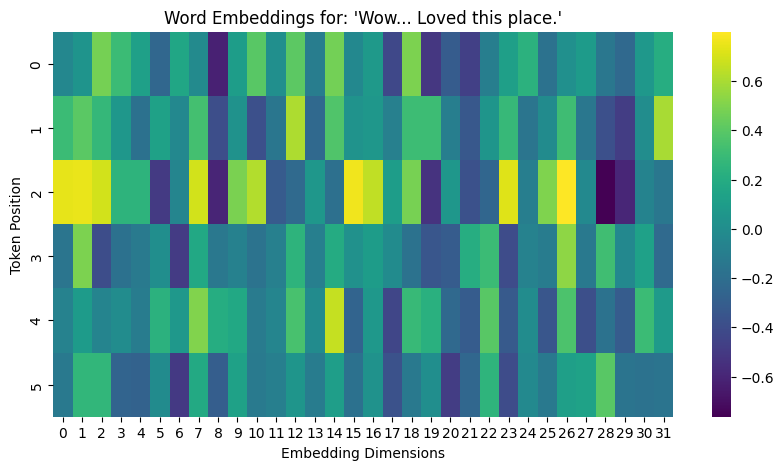

In [ ]:
# helper functions

#print_embedding_info(transformer_model)

## Positional Encoding

Since our model contains no recurrence and no convolution, in order for the model to make use of the order of the sequence, we must inject some information about the relative or absolute position of the tokens in the sequence. To this end, we add “positional encodings” to the input embeddings at the bottoms of the decoder stacks. The positional encodings have the same dimension $d_{model}$ as the embeddings, so that the two can be summed. There are many choices of positional encodings, learned and fixed.

In this work, we use sine and cosine functions of different frequencies:

$
PE_{(pos, 2i)} = \sin \left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$

$
PE_{(pos, 2i+1)} = \cos \left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$

 where $pos$ is the position and $i$ is the dimension. That is, each dimension of the positional encoding corresponds to a sinusoid. The wavelengths form a geometric progression from $2π$ to $10000 ⋅ 2π$. We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$.

In addition, we apply dropout to the sums of the embeddings and the positional encodings in both the decoder stacks. For the base model, we use a rate of $P_{drop} = 0.1$.

In [ ]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)],
                         requires_grad=False)
        return self.dropout(x)

Below the positional encoding will add in a sine wave based on position. The frequency and offset of the wave is different for each dimension.

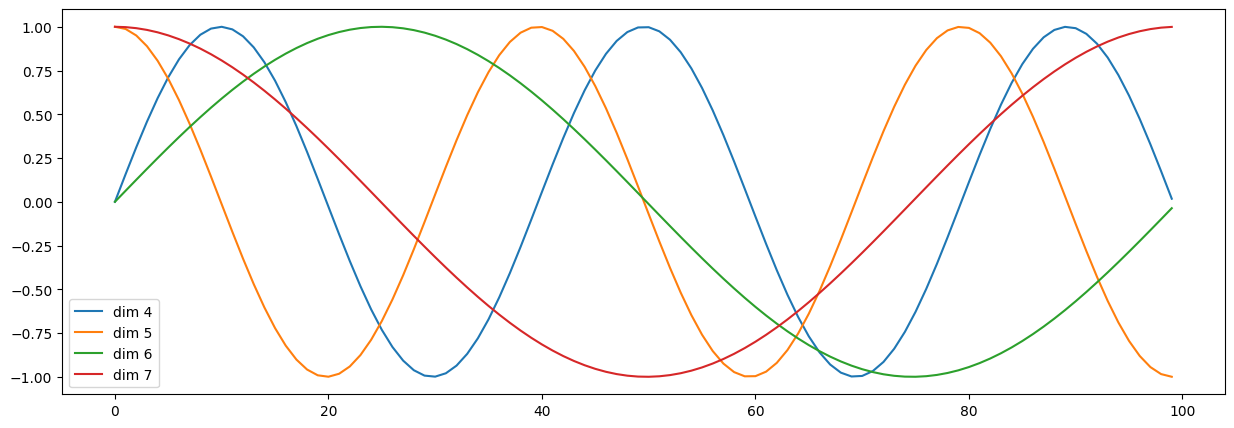

In [ ]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])

## Position-wise Feed-Forward Networks

In addition to attention sub-layers, each of the layers in our decoder contains a fully connected feed-forward network, which is applied to each position separately and identically. This consists of two linear transformations with a ReLU activation in between:

$$
FFN(x) = \max(0, x W_1 + b_1) W_2 + b_2
$$

While the linear transformations are the same across different positions, they use different parameters from layer to layer. Another way of describing this is as two convolutions with kernel size 1.


In [ ]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

## Attention

An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key.

We call our particular attention “Scaled Dot-Product Attention”. The input consists of queries and keys of dimension $d_k$
, and values of dimension $d_v$. We compute the dot products of the query with all keys, divide each by $√d_k$, and apply a softmax function to obtain the weights on the values.

In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix $Q$. The keys and values are also packed together into matrices $K$ and $V$. We compute the matrix of outputs as:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^\top}{\sqrt{d_k}}\right)V
$$


In [ ]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \, W_O
$$

where

$$
\text{head}_i = \text{Attention}(Q \, W_{Q_i}, \; K \, W_{K_i}, \; V \, W_{V_i})
$$

where the projections are parameter matrices

$$
W_{Q_i} \in \mathbb{R}^{d_{\text{model}} \times d_k}, \quad
W_{K_i} \in \mathbb{R}^{d_{\text{model}} \times d_k}, \quad
W_{V_i} \in \mathbb{R}^{d_{\text{model}} \times d_v}, \quad
W_O \in \mathbb{R}^{h d_v \times d_{\text{model}}}.
$$

Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality.


In [ ]:
# details : https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # We assume d_v always equals d_k
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        "Implements Figure 2"
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) Do all the linear projections in batch from d_model => h x d_k
        query, key, value = \
            [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
             for l, x in zip(self.linears, (query, key, value))]

        # 2) Apply attention on all the projected vectors in batch.
        x, self.attn = attention(query, key, value, mask=mask,
                                 dropout=self.dropout)

        # 3) "Concat" using a view and apply a final linear.
        x = x.transpose(1, 2).contiguous() \
             .view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

## Decoder architecture

The transformer model we're building here is also called a *transformer decoder*, because each target word can only attend to previous words on the left.  As such, we'll need to imeplement some masking for the attention to prevent a target word from attending to future words on the right. We'll get to that in a bit. For now, let's define the decoder, which is composed of a stack of $N$ identical decoder layers.

In [ ]:
# This is a clone layer, which duplicate the same layer N time based on the the input module.
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [ ]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)

    def forward(self, x, tgt_mask):
        for layer in self.layers:
            x = layer(x, tgt_mask)
        return x

Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a position-wise fully connected feed- forward network.

In [ ]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn and feed forward (defined below)"

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)

    def forward(self, x, tgt_mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        return self.sublayer[1](x, self.feed_forward)

We will now modify the self-attention sub-layer in the decoder stack to prevent current words from attending to words on the right. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position $i$ can depend only on the known outputs at positions less than $i$.

In [ ]:
def subsequent_mask(size):
    "Mask out words in subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8
    )
    return subsequent_mask == 0

Below the attention mask shows the position each tgt word (row) is allowed to look at (column). Words are blocked for attending to future words during training.

In [ ]:
LS_data = pd.concat(
    [
        pd.DataFrame(
            {
                "Subsequent Mask": subsequent_mask(20)[0][x, y].flatten(),
                "Window": y,
                "Masking": x,
            }
        )
        for y in range(20)
        for x in range(20)
    ]
)

alt.Chart(LS_data).mark_rect().properties(height=250, width=250).encode(
    alt.X("Window:O"),
    alt.Y("Masking:O"),
    alt.Color("Subsequent Mask:Q", scale=alt.Scale(scheme="viridis")),
).interactive()

alt.Chart(...)

### Masking visualisation

Please run after initiating the model and helper functions

Self-Attention summary:
Number of attention heads: 4
Dimension per head: 8
Total attention dimension: 32
Attention weights shape: (9, 9)


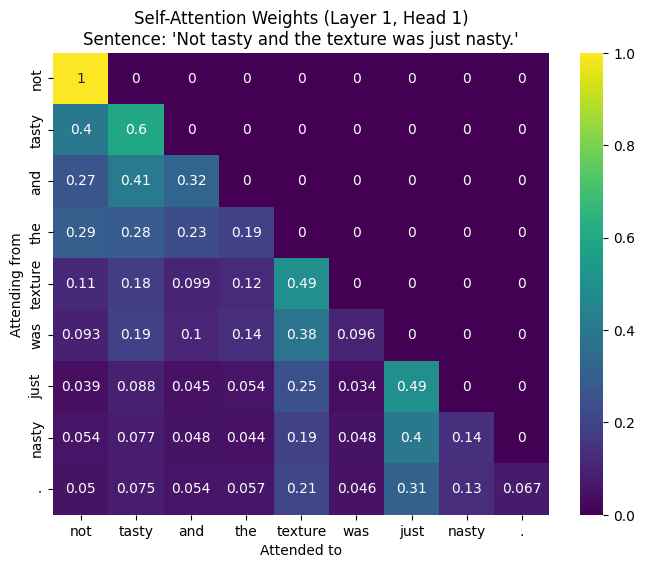

In [ ]:
# helper functions

#sample_sentence = sentences_train[2]
#visualize_attention(transformer_model, sample_sentence)

We now define layer normalisation.


In [ ]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

Recall that we have a residual connection before layer norm:
$$
\text{LayerNorm}(x + \text{Sublayer}(x))
$$
where $\text{Sublayer}(x)$ is the function implemented by the sub-layer itself. We apply dropout to the output of each sub-layer, before it is added to the sub-layer input and normalized.


In [ ]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return self.dropout(self.norm(x + sublayer(x)))


## The Complete Vanilla Transformer Sentiment Classification Model

We are now ready to implement the full transformer!

![Trasnformer](https://github.com/jhlau/jhlau.github.io/blob/master/files/comp90042/transformer.png?raw=true)

In [ ]:
# hyperparameters
vocab_size = len(vocab)
num_layers = 2
d_model = 32
d_ff = 64
h = 4
dropout = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N = 2
#max_len = 20
#batch_size = 10

In [ ]:
class TransformerDecoderSentimentAnalyzer(nn.Module):

  def __init__(self, vocab_size, N=2,
               d_model=32, d_ff=64, h=4, dropout=0.1):
    super(TransformerDecoderSentimentAnalyzer, self).__init__()
    # This is a deep copy function.
    c = copy.deepcopy

    # Initiate a template of multihead attention layers based on the params.
    attn = MultiHeadedAttention(h, d_model)
    # Initiate a template of the Positionwise feed forward layer.
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    # Initiate the position encoder.
    position = PositionalEncoding(d_model, dropout)

    # We link the embedding and position embedding together.
    self.embed = nn.Sequential(Embeddings(d_model, vocab_size), c(position))

    # We initiate the Decoder based on the parameters.
    self.decoder = Decoder(DecoderLayer(d_model, c(attn), c(ff), dropout), N)

    self.fc = nn.Linear(d_model, 1)


  def forward(self, input):
    src = input[0]
    padding_mask = input[1]

    tgt_mask = subsequent_mask(src.shape[1]).to(src.device)

    # # Here we combine the two masks: padding mask and subsequence mask
    # tgt_mask = sub_mask * src_mask.unsqueeze(1)
    embedding = self.embed(src)
    decoder_output = self.decoder(embedding, tgt_mask)

    # From the last padding_mask we get the index of the non-padding token for each sentence.
    last_indices = padding_mask.sum(dim=1) - 1
    batch_indices = torch.arange(decoder_output.size(0)).to(decoder_output.device)
    # Use advanced indexing to retrieve the specific output for each sentence.
    selected_outputs = decoder_output[batch_indices, last_indices, :]

    # Use the hidden state of the last non-padding token from the decoder's output (last time step)
    # Shape: (batch_size, embed_dim)
    logits = torch.sigmoid(self.fc(selected_outputs))
    return logits

## Dataloader pipeline

We need to create a new dataloader pipeline that is very similar to the sequence model dataloader we have built before, except:


*   We add a special token <cls> at the beginning of each sequence
*   We output an additional attention mask, so that the transformer will ignore those padding tokens.



In [ ]:
def transformer_tokenizer(x, vocab):
    tokens = tokenizer(x)
    return [vocab.get(token, default_index) for token in tokens]

def transformer_seq_collate_batch(batch):
    label_list, text_list = [], []
    for _text, _label in batch:
        label_list.append(_label)
        text_list.append(transformer_tokenizer(_text, vocab))
    label_list = torch.tensor(label_list, dtype=torch.float32)

    padded_sequences = []
    attention_masks = []
    for seq in text_list:
        # Truncate if longer than max_len
        truncated_seq = seq[:max_len]
        # Pad if shorter
        padded_seq = truncated_seq + [padding_index] * (max_len - len(truncated_seq))
        padded_sequences.append(torch.tensor(padded_seq))
        # Create attention mask: 1 for non-padding tokens, 0 for padding tokens
        mask = [1 if token != padding_index else 0 for token in padded_seq]
        attention_masks.append(torch.tensor(mask))

    text_tensor = torch.stack(padded_sequences)
    mask_tensor = torch.stack(attention_masks)

    return (text_tensor.to(device), mask_tensor.to(device)), label_list.reshape(-1, 1).to(device)

# Set maximum sequence length.
max_len = 20

# Create data loaders.
xseq_train_dataloader = DataLoader(
    list(zip(sentences_train, y_train)),
    batch_size=10,
    collate_fn=transformer_seq_collate_batch
)
xseq_dev_dataloader = DataLoader(
    list(zip(sentences_dev, y_dev)),
    batch_size=10,
    collate_fn=transformer_seq_collate_batch
)
xseq_test_dataloader = DataLoader(
    list(zip(sentences_test, y_test)),
    batch_size=10,
    collate_fn=transformer_seq_collate_batch
)


### Model summary
Please run after initiating the model and helper function

In [ ]:
# helper functions

# print_comprehensive_model_summary(transformer_model, sentences_train[0])

TRANSFORMER MODEL COMPREHENSIVE SUMMARY

1. ARCHITECTURE OVERVIEW
------------------------------
Vocabulary size: 1,813
Embedding dimension (d_model): 32
Number of decoder layers: 2
Number of attention heads (h): 4
Dimension per attention head: 8
Feed-forward hidden dimension (d_ff): 64
Dropout rate: 0.1

2. PARAMETER COUNTS
------------------------------
Embedding layer: 58,016 parameters
Decoder layers: 17,088 parameters
Classifier: 33 parameters
Total: 75,137 parameters

3. COMPONENT DIMENSIONS
------------------------------
Embedding layer:
  Input: Tokens with vocabulary size 1,813
  Output: Vectors of dimension 32

Multi-Head Attention:
  Input: Sequence of vectors with dimension 32
  Q, K, V projections: 4 heads × 8 dimensions = 32
  Output: Sequence of vectors with dimension 32

Position-wise Feed-Forward Network:
  Input dimension: 32
  Hidden dimension: 64
  Output dimension: 32

Output Classifier:
  Input dimension: 32
  Output dimension: 1 (sigmoid applied for binary classi

## Training and Testing



In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    # Calling .train() will evoke the tensor to start caching steps and gradients.
    model.train()
    for batch, (X, y) in enumerate(dataloader):

        # Compute prediction by directly calling the model variable.
        pred = model(X)
        # Calculate the loss by comparing the prediction and the true labels.
        loss = loss_fn(pred, y)

        # Backpropagation: calculate the gradient by walking back the cached steps.
        loss.backward()
        # Update the parameters of the model with the loss gradient.
        optimizer.step()
        # Remove all the gradient to be ready for the next training of the next batch.
        optimizer.zero_grad()

        if batch  == size - 1:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # After calling eval(), the model no longer caching steps and gradient.
    # The model also does the inference faster with less resource.
    model.eval()
    test_loss, correct = 0, 0
    # This line specify that there will be no gradient in the operation below.
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            result = (pred>0.5).float()
            correct += (result == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Performance: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
print("Training transformer sentiment analysis model!")

transformer_model = TransformerDecoderSentimentAnalyzer(vocab_size, 2, d_model=32, d_ff=64, h=4, dropout=0.1).to(device)
num_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
for p in transformer_model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
print(f"Total trainable parameters: {num_params}")

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)
epochs = 30


for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train(xseq_train_dataloader, transformer_model, loss_fn, optimizer)
    test(xseq_dev_dataloader, transformer_model, loss_fn)
print("Done!")

print("final test:")
test(xseq_test_dataloader, transformer_model, loss_fn)

Training transformer sentiment analysis model!
Total trainable parameters: 75137
Epoch 1
-------------------------------
Test Performance: 
 Accuracy: 44.0%, Avg loss: 0.791382 

Epoch 2
-------------------------------
Test Performance: 
 Accuracy: 74.0%, Avg loss: 0.537618 

Epoch 3
-------------------------------
Test Performance: 
 Accuracy: 81.0%, Avg loss: 0.437607 

Epoch 4
-------------------------------
Test Performance: 
 Accuracy: 77.0%, Avg loss: 0.871200 

Epoch 5
-------------------------------
Test Performance: 
 Accuracy: 79.0%, Avg loss: 0.871976 

Epoch 6
-------------------------------
Test Performance: 
 Accuracy: 72.0%, Avg loss: 1.223615 

Epoch 7
-------------------------------
Test Performance: 
 Accuracy: 86.0%, Avg loss: 0.541679 

Epoch 8
-------------------------------
Test Performance: 
 Accuracy: 78.0%, Avg loss: 0.707386 

Epoch 9
-------------------------------
Test Performance: 
 Accuracy: 77.0%, Avg loss: 0.941648 

Epoch 10
----------------------------

Does the Transformer model work better than the LSTM model? Does increasing the number of model parameters improve performance?

### Sample data processing
Please run after initiating the model and helper functions

In [ ]:
# helper functions - Take 5 samples from training data

#sample_sentences = sentences_train[:5]
#sample_labels = y_train[:5]
#visualize_sample_processing()

Sample Data Processing:

Sample 1:
Text: 'Wow... Loved this place.'
Label: 1 (Positive)
Tokenized: ['wow', '...', 'loved', 'this', 'place', '.']
Token IDs: [3, 4, 5, 6, 7, 8]
After truncation/padding (max_len=20): [3, 4, 5, 6, 7, 8, 2, 2, 2, 2]...
Attention mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]...
Embedding shape: torch.Size([1, 20, 32])
Prediction: 0.9998 (Positive)
----------------------------------------

Sample 2:
Text: 'Crust is not good.'
Label: 0 (Negative)
Tokenized: ['crust', 'is', 'not', 'good', '.']
Token IDs: [9, 10, 11, 12, 8]
After truncation/padding (max_len=20): [9, 10, 11, 12, 8, 2, 2, 2, 2, 2]...
Attention mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]...
Embedding shape: torch.Size([1, 20, 32])
Prediction: 0.0024 (Negative)
----------------------------------------

Sample 3:
Text: 'Not tasty and the texture was just nasty.'
Label: 0 (Negative)
Tokenized: ['not', 'tasty', 'and', 'the', 'texture', 'was', 'just', 'nasty', '.']
Token IDs: [11, 13, 14, 15, 16, 17, 18, 19, 8]
After t

## Helper functions

In [ ]:
# After this, run the code at Embedding visualsation

def print_embedding_info(model):
    embed_params = sum(p.numel() for p in model.embed.parameters())
    print(f"Embedding layer summary:")
    print(f"Vocabulary size: {len(vocab)}")
    print(f"Embedding dimension: {model.embed[0].d_model}")
    print(f"Parameter count: {embed_params:,}")

    # Visualize a sample sentence embedding
    sample_text = sentences_train[0]  # "Wow... Loved this place."
    tokens = transformer_tokenizer(sample_text, vocab)
    token_tensor = torch.tensor([tokens]).to(device)

    # Get embeddings without positional encoding (grab first part of sequential)
    embedding_layer = model.embed[0]
    embeddings = embedding_layer(token_tensor)

    print(f"\nSample text: '{sample_text}'")
    print(f"Tokenized: {[index_to_vocab[t] for t in tokens]}")
    print(f"Token IDs: {tokens}")
    print(f"Embedding shape (Before truncation/padding): {embeddings.shape}")
    print(f"First token embedding (first 5 dims): {embeddings[0][0][:5].detach().cpu().numpy()}")

    # Visualize embeddings with a heatmap
    plt.figure(figsize=(10, 5))
    plt.title(f"Word Embeddings for: '{sample_text}'")
    sns.heatmap(embeddings[0].detach().cpu().numpy(), cmap='viridis')
    plt.xlabel("Embedding Dimensions")
    plt.ylabel("Token Position")
    plt.show()

# Example
print_embedding_info(transformer_model)

In [ ]:
# After this, run the code at Masking visualsation

def visualize_attention(model, sentence):
    # Tokenize and prepare input
    tokens = transformer_tokenizer(sentence, vocab)
    token_names = [index_to_vocab.get(t, '<unk>') for t in tokens]
    token_tensor = torch.tensor([tokens]).to(device)
    mask_tensor = torch.tensor([[1] * len(tokens)]).to(device)

    # Set model to eval mode for visualization
    model.eval()

    # Create the mask for causal attention
    tgt_mask = subsequent_mask(len(tokens)).to(device)

    # Create a hook to capture attention weights
    attention_weights = []
    def hook_fn(module, input, output):
        attention_weights.append(module.attn.detach().cpu().numpy())

    # Register the hook on the first self-attention layer
    hook = model.decoder.layers[0].self_attn.register_forward_hook(hook_fn)

    # Forward pass
    with torch.no_grad():
        _ = model((token_tensor, mask_tensor))

    # Remove the hook
    hook.remove()

    # Set model back to train mode
    model.train()

    # Get attention weights from the first layer, first head
    attn = attention_weights[0][0, 0]  # [batch, num_heads, seq_len, seq_len]

    print(f"Self-Attention summary:")
    print(f"Number of attention heads: {model.decoder.layers[0].self_attn.h}")
    print(f"Dimension per head: {model.decoder.layers[0].self_attn.d_k}")
    print(f"Total attention dimension: {model.decoder.layers[0].self_attn.h * model.decoder.layers[0].self_attn.d_k}")
    print(f"Attention weights shape: {attn.shape}")

    # Visualize attention map for the first head
    plt.figure(figsize=(8, 6))
    plt.title(f"Self-Attention Weights (Layer 1, Head 1)\nSentence: '{sentence}'")
    sns.heatmap(attn, annot=True, cmap='viridis', xticklabels=token_names, yticklabels=token_names)
    plt.xlabel('Attended to')
    plt.ylabel('Attending from')
    plt.show()

# Example
sample_sentence = sentences_train[0]
visualize_attention(transformer_model, sample_sentence)

In [ ]:
# After this, run the code at Model summary

def print_comprehensive_model_summary(model, sample_sentence=None):
    # Count parameters by component
    embedding_params = sum(p.numel() for p in model.embed.parameters() if p.requires_grad)
    decoder_params = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)
    classifier_params = sum(p.numel() for p in model.fc.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Get model hyperparameters
    d_model = model.decoder.layers[0].size
    d_ff = model.decoder.layers[0].feed_forward.w_1.out_features
    h = model.decoder.layers[0].self_attn.h
    num_layers = len(model.decoder.layers)
    dropout_rate = model.decoder.layers[0].self_attn.dropout.p

    # Print summary table
    print(f"{'=' * 60}")
    print(f"TRANSFORMER MODEL COMPREHENSIVE SUMMARY")
    print(f"{'=' * 60}")

    print(f"\n1. ARCHITECTURE OVERVIEW")
    print(f"{'-' * 30}")
    print(f"Vocabulary size: {len(vocab):,}")
    print(f"Embedding dimension (d_model): {d_model}")
    print(f"Number of decoder layers: {num_layers}")
    print(f"Number of attention heads (h): {h}")
    print(f"Dimension per attention head: {d_model // h}")
    print(f"Feed-forward hidden dimension (d_ff): {d_ff}")
    print(f"Dropout rate: {dropout}")

    print(f"\n2. PARAMETER COUNTS")
    print(f"{'-' * 30}")
    print(f"Embedding layer: {embedding_params:,} parameters")
    print(f"Decoder layers: {decoder_params:,} parameters")
    print(f"Classifier: {classifier_params:,} parameters")
    print(f"Total: {total_params:,} parameters")

    print(f"\n3. COMPONENT DIMENSIONS")
    print(f"{'-' * 30}")

    # Embedding dimensions
    print(f"Embedding layer:")
    print(f"  Input: Tokens with vocabulary size {len(vocab):,}")
    print(f"  Output: Vectors of dimension {d_model}")

    # Attention dimensions
    print(f"\nMulti-Head Attention:")
    print(f"  Input: Sequence of vectors with dimension {d_model}")
    print(f"  Q, K, V projections: {h} heads × {d_model // h} dimensions = {d_model}")
    print(f"  Output: Sequence of vectors with dimension {d_model}")

    # Feed-forward dimensions
    print(f"\nPosition-wise Feed-Forward Network:")
    print(f"  Input dimension: {d_model}")
    print(f"  Hidden dimension: {d_ff}")
    print(f"  Output dimension: {d_model}")

    # Output classifier dimensions
    print(f"\nOutput Classifier:")
    print(f"  Input dimension: {d_model}")
    print(f"  Output dimension: 1 (sigmoid applied for binary classification)")

    # Process a sample sentence
    if sample_sentence is None and len(sentences_train) > 0:
        sample_sentence = sentences_train[0]  # Use the first training example

    if sample_sentence:
        print(f"\n4. SAMPLE DATA FLOW")
        print(f"{'-' * 30}")
        print(f"Sample: '{sample_sentence}'")

        # Tokenization and indexing
        tokens = tokenizer(sample_sentence)
        token_ids = [vocab.get(token, default_index) for token in tokens]
        # Truncation/padding for model input
        truncated = token_ids[:max_len]
        padded = truncated + [padding_index] * (max_len - len(truncated))
        mask = [1 if token != padding_index else 0 for token in padded]

        print(f"\nTokenization:")
        print(f"  Tokens: {tokens}")
        print(f"  Token IDs: {token_ids}")
        print(f"  After truncation/padding (max_len={max_len}): {padded[:10]}...")
        print(f"  Sequence length: {len(padded)}")

        # Create input tensors
        token_tensor = torch.tensor([padded]).to(device)
        mask_tensor = torch.tensor([mask]).to(device)

        # Trace through the model with hooks
        shapes = {}
        hooks = []

        def get_hook(name):
            def hook(module, input, output):
                if isinstance(output, tuple):
                    shapes[name] = (output[0].shape, "attention_map:", output[1].shape)
                else:
                    shapes[name] = output.shape
            return hook

        # Register hooks on key components
        hooks.append(model.embed[0].register_forward_hook(get_hook("token_embedding")))
        hooks.append(model.embed.register_forward_hook(get_hook("embedding_with_pos")))

        for i, layer in enumerate(model.decoder.layers):
            hooks.append(layer.self_attn.register_forward_hook(get_hook(f"attention_{i}")))
            hooks.append(layer.feed_forward.register_forward_hook(get_hook(f"ffn_{i}")))
            hooks.append(layer.register_forward_hook(get_hook(f"decoder_layer_{i}_output")))

        # Trace shape transformations through feed-forward network
        ffn = model.decoder.layers[0].feed_forward
        hooks.append(ffn.w_1.register_forward_hook(get_hook("ffn_first_linear")))
        hooks.append(ffn.w_2.register_forward_hook(get_hook("ffn_second_linear")))

        # Dummy forward pass to collect shapes
        with torch.no_grad():
            model.eval()  # Set to eval mode temporarily
            output = model((token_tensor, mask_tensor))
            model.train()  # Set back to training mode

        # Remove hooks
        for hook in hooks:
            hook.remove()

        # Print shape transformations
        print(f"\nShape Transformations:")
        print(f"  Input token IDs: {token_tensor.shape}")
        print(f"  Attention mask: {mask_tensor.shape}")

        print(f"\n  Embedding Layer:")
        print(f"    After token embedding: {shapes['token_embedding']}")
        print(f"    After positional encoding: {shapes['embedding_with_pos']}")

        print(f"\n  Decoder Layers:")
        for i in range(len(model.decoder.layers)):
            print(f"    Layer {i+1}:")
            print(f"      Self-attention: {shapes[f'attention_{i}']}")
            print(f"      Feed-forward network: {shapes[f'ffn_{i}']}")
            print(f"      Layer output: {shapes[f'decoder_layer_{i}_output']}")

        print(f"\n  Feed-Forward Network (from first decoder layer):")
        print(f"    First linear (d_model → d_ff): {shapes['ffn_first_linear']}")
        print(f"    Second linear (d_ff → d_model): {shapes['ffn_second_linear']}")

        # Last non-padding token selection
        print(f"\n  Final Classification:")
        print(f"    Select last non-padding token: [{token_tensor.size(0)}, {d_model}]")
        print(f"    Linear classifier output: [{token_tensor.size(0)}, 1]")
        print(f"    Final output (probabilities): {output.item():.4f} ({'Positive' if output.item() > 0.5 else 'Negative'})")


        # Input/output shapes for a sample batch
        print(f"\n5. SAMPLE BATCH FLOW")
        print(f"{'-' * 30}")

        sample_batch = next(iter(xseq_train_dataloader))
        inputs, targets = sample_batch

        print(f"  Batch dimensions (batch_size=10, seq_length={max_len}):")
        print(f"  Input token: {inputs[0].shape}")
        print(f"  Attention mask: {inputs[1].shape}")
        print(f"  Target labels: {targets.shape}")

        # Forward pass with hooks to capture intermediate shapes
        shapes = {}
        hooks = []

        def get_hook(name):
            def hook(module, input, output):
                shapes[name] = output.shape
            return hook

        # Register hooks on key components
        hooks.append(model.embed.register_forward_hook(get_hook("embeddings")))
        for i, layer in enumerate(model.decoder.layers):
            hooks.append(layer.self_attn.register_forward_hook(get_hook(f"self_attn_{i}")))
            hooks.append(layer.feed_forward.register_forward_hook(get_hook(f"ffn_{i}")))

        with torch.no_grad():
            model.eval()
            batch_output = model(inputs)
            model.train()

        # Remove hooks
        for hook in hooks:
            hook.remove()

        # Print intermediate shapes
        print(f"\nIntermediate shapes:")
        print(f"  After embeddings: {shapes['embeddings']}")
        for i in range(len(model.decoder.layers)):
            print(f"  After self-attention (layer {i+1}): {shapes[f'self_attn_{i}']}")
            print(f"  After feed-forward (layer {i+1}): {shapes[f'ffn_{i}']}")

        # Final output shape
        print(f"  Final output (probabilities): {batch_output.shape}")

    print(f"\n{'=' * 60}")

# Example
print_comprehensive_model_summary(transformer_model, sentences_train[0])

In [ ]:
# After this, run the code at Sample data processing

def visualize_sample_processing():
    # Take 5 samples from training data
    sample_sentences = sentences_train[:5]
    sample_labels = y_train[:5]

    print("Sample Data Processing:")
    print("=" * 80)

    for i, (sentence, label) in enumerate(zip(sample_sentences, sample_labels)):
        print(f"\nSample {i+1}:")
        print(f"Text: '{sentence}'")
        print(f"Label: {label} ({'Positive' if label == 1 else 'Negative'})")

        # Tokenization
        tokens = tokenizer(sentence)
        print(f"Tokenized: {tokens}")

        # Convert to IDs
        token_ids = [vocab.get(token, default_index) for token in tokens]
        print(f"Token IDs: {token_ids}")

        # Truncation/padding for model input
        truncated = token_ids[:max_len]
        padded = truncated + [padding_index] * (max_len - len(truncated))
        print(f"After truncation/padding (max_len={max_len}): {padded[:10]}...")

        # Attention mask
        mask = [1 if token != padding_index else 0 for token in padded]
        print(f"Attention mask: {mask[:10]}...")

        # Create tensors
        tokens_tensor = torch.tensor([padded]).to(device)
        mask_tensor = torch.tensor([mask]).to(device)

        # Process through model
        with torch.no_grad():
            # Get embeddings
            embedded = transformer_model.embed(tokens_tensor)
            print(f"Embedding shape: {embedded.shape}")

            # Get prediction
            prediction = transformer_model((tokens_tensor, mask_tensor))
            print(f"Prediction: {prediction.item():.4f} ({'Positive' if prediction.item() > 0.5 else 'Negative'})")

        print("-" * 40)

# Example
visualize_sample_processing()